# Monotonic SVM
The Monotonic SVM solves the following optimization problem:

$$
  \min_{\mathbf{\beta} \in \mathbb{R}^d} C\sum_{i=1}^n (1 - y_i \mathbf{\beta}^\intercal \mathbf{x}_i)_+ + \frac{1}{2} \|\mathbf{\beta}\|_2^2,
$$
$$
  \text{subject to} \quad \beta_j \le \beta_{j+1} \quad \forall j \in \{1, \dots, d-1\} \quad (\text{Increasing})
$$
$$
  \text{or} \quad \beta_j \ge \beta_{j+1} \quad \forall j \in \{1, \dots, d-1\} \quad (\text{Decreasing})
$$

where:

* $\mathbf{x}_i \in \mathbb{R}^d$ is a feature vector
* $y_i \in \{-1, 1\}$ is a binary label
* $\beta_j$ represents the $j$-th component of the coefficient vector $\mathbf{\beta}$

The monotonicity constraints ensure that the learned coefficients $\beta$ follow a strictly non-decreasing or non-increasing order, useful when incorporating prior domain knowledge.

> **Note.** Since the hinge loss is a plq function and the monotonicity constraints are purely linear (e.g., $\beta_j - \beta_{j+1} \le 0$), we can optimize it using `rehline.plq_Ridge_Classifier`.


In [ ]:
## install rehline
%pip install rehline -q

In [2]:
## simulate data
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

n, d = 10000, 5
X, y = make_classification(n_samples=n, n_features=d, n_redundant=0, random_state=42)
y = 2*y - 1
X = scaler.fit_transform(X)

## SVM as baseline

In [3]:
## we first run a SVM
from rehline import plq_Ridge_Classifier

clf = plq_Ridge_Classifier(loss={'name': 'svm'}, C=0.001, max_iter=10000)
clf.fit(X=X, y=y)

plq_Ridge_Classifier(C=0.001, loss={'name': 'svm'}, max_iter=10000)

## Monotonic constraint

In [4]:
## solve SVM with Monotonicity Constraint via `plq_Ridge_Classifier`
from rehline import plq_Ridge_Classifier
mclf = plq_Ridge_Classifier(
    loss={'name': 'svm'},
    constraint = [{'name': 'monotonic', 'decreasing': True}],
    C=0.001,
    max_iter=10000
)
mclf.fit(X=X, y=y)

plq_Ridge_Classifier(C=0.001,
                     constraint=[{'decreasing': True, 'name': 'monotonic'}],
                     loss={'name': 'svm'}, max_iter=10000)

## Results

In [5]:
import pandas as pd

## score
score  = clf.decision_function(X)
mscore = mclf.decision_function(X)

svm_perf  = clf.score(X, y)
msvm_perf = mclf.score(X, y)

## Create a pandas DataFrame to store the results
results = pd.DataFrame({
    'Model': ['Standard SVM', 'Monotonic SVM'],
    'Performance': [svm_perf, msvm_perf]
})

## Print the results as a table
print(results.to_string(index=False))

        Model  Performance
 Standard SVM       0.8870
Monotonic SVM       0.7332


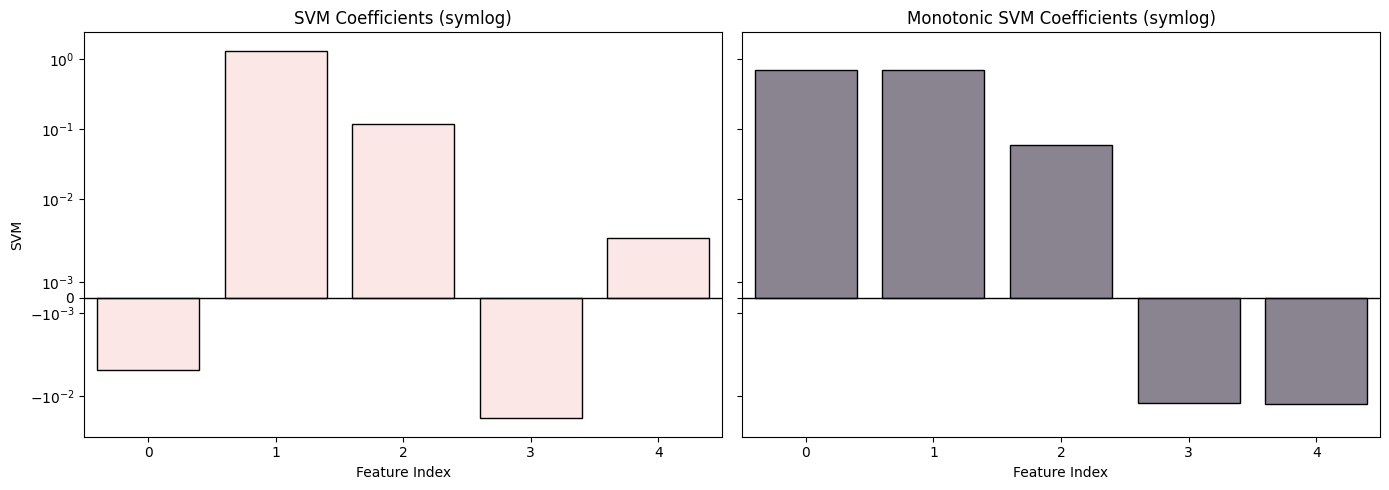


Coefficients (monotonic decreasing):
[ 0.6899   0.68989  0.05962 -0.0126  -0.01276]
Monotonic descreasing satisfied: True


In [6]:
## Visualize the feature coefficients
import seaborn as sns
import matplotlib.pyplot as plt

df_coef = pd.DataFrame({
    'Feature Index': range(len(clf.coef_.flatten())),
    'SVM': clf.coef_.flatten(),
    'Monotonic SVM': mclf.coef_.flatten()
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.barplot(data=df_coef, x="Feature Index", y="SVM", ax=axes[0], color='#FFE4E1', edgecolor='black')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_yscale('symlog', linthresh=0.005)
axes[0].set_title("SVM Coefficients (symlog)")

sns.barplot(data=df_coef, x="Feature Index", y="Monotonic SVM", color='#8A8293', ax=axes[1], edgecolor='black')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_yscale('symlog', linthresh=0.005)
axes[1].set_title("Monotonic SVM Coefficients (symlog)")
plt.tight_layout()
plt.show()

## Print the results of monotonic constraint
np.set_printoptions(precision=5, suppress=True)
print("\nCoefficients (monotonic decreasing):")
print(mclf.coef_)
print("Monotonic descreasing satisfied:",
      np.all(mclf.coef_[:-1] >= mclf.coef_[1:]))


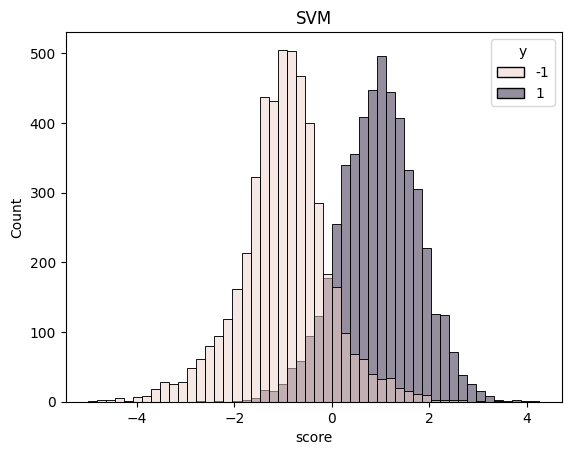

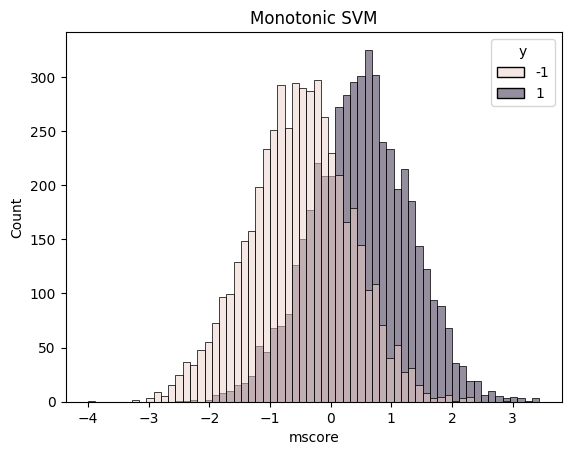

In [7]:
import warnings
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

df = pd.DataFrame({'score': score, 'mscore': mscore, 'y': y})

sns.histplot(df, x="score", hue="y").set_title("SVM")
plt.show()
sns.histplot(df, x="mscore", hue="y").set_title("Monotonic SVM")
plt.show()